In [2]:
from pathlib import Path
import json
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr, spearmanr

from IPython.display import display

warnings.filterwarnings("ignore")

In [3]:
# ============================================================
# Project / run configuration
# ============================================================
DEFAULT_PROJECT_ROOT = Path("/work/pi_rsitaram_umass_edu/tungi/ekb-claude-pilot")
PROJECT_ROOT = DEFAULT_PROJECT_ROOT if DEFAULT_PROJECT_ROOT.exists() else Path.cwd().resolve()

# Change this to the run folder you want to analyze
RUN_NAME = "gaia_lv1_x4"

RUN_ROOT = PROJECT_ROOT / "traces" / "claude_native" / RUN_NAME

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RUN_ROOT:", RUN_ROOT)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def load_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def iter_normalized_trace_paths(run_root: Path):
    if not run_root.exists():
        raise FileNotFoundError(f"Trace root does not exist: {run_root}")
    for path in sorted(run_root.glob("*/normalized_trace.json")):
        yield path

def canonical_tool_name(tool):
    if tool is None:
        return "unknown"
    tool = str(tool).strip()
    mapping = {
        "WebSearch": "WebSearch",
        "WebFetch": "WebFetch",
        "Bash": "Bash",
        "Read": "Read",
        "Write": "Write",
        "Edit": "Edit",
        "Grep": "Grep",
        "Glob": "Glob",
        "ToolSearch": "ToolSearch",
        "StructuredOutput": "StructuredOutput",
    }
    return mapping.get(tool, tool)

def extract_steps(trace: dict):
    steps = trace.get("steps", [])
    if not isinstance(steps, list):
        return []

    out = []
    for s in steps:
        if not isinstance(s, dict):
            continue
        out.append({
            "step": s.get("step"),
            "tool": canonical_tool_name(s.get("tool")),
            "status": s.get("status"),
            "latency_ms": s.get("latency_ms"),
        })
    return out

def safe_num(x, default=np.nan):
    try:
        if x is None:
            return default
        return float(x)
    except Exception:
        return default

def build_trace_record(path: Path):
    trace = load_json(path)
    steps = extract_steps(trace)

    tools_all = [s["tool"] for s in steps]
    tool_counts = Counter(tools_all)

    record = {
        "query_id": trace.get("query_id"),
        "query_text": trace.get("query_text", ""),
        "benchmark": trace.get("benchmark"),
        "split": trace.get("split"),
        "level": trace.get("level"),
        "agent": trace.get("agent"),
        "model_requested": trace.get("model_requested"),
        "effort": trace.get("effort"),

        # scalar execution attributes
        "total_steps": int(trace.get("total_steps", len(steps) or 0)),
        "total_tool_calls": int(trace.get("total_tool_calls", len(steps) or 0)),
        "total_latency_ms": safe_num(trace.get("total_latency_ms")),
        "total_tokens": safe_num(trace.get("total_tokens")),

        # sequence / set views
        "tool_sequence_all": tools_all,
        "tools_used": sorted(set(tools_all)),

        # answer/eval fields
        "success": trace.get("success"),
        "final_answer_pred": trace.get("final_answer_pred"),
        "ground_truth_answer": trace.get("ground_truth_answer"),
        "exact_match": trace.get("exact_match"),
        "result_text": trace.get("result_text"),

        # bookkeeping
        "normalized_trace_path": str(path),
        "task_dir": str(path.parent),
        "run_name": path.parent.parent.name,
        "task_folder_name": path.parent.name,

        # keep raw tool counts temporarily for dense expansion later
        "_tool_counts": dict(tool_counts),
    }
    return record

# ============================================================
# Load traces
# ============================================================
trace_paths = list(iter_normalized_trace_paths(RUN_ROOT))
print(f"Found {len(trace_paths)} normalized_trace.json files under {RUN_ROOT}")

trace_records = [build_trace_record(p) for p in trace_paths]
df_all = pd.DataFrame(trace_records)

print(f"Loaded {len(df_all)} normalized traces.")

# ------------------------------------------------------------
# Expand dense tool_count__* columns
# ------------------------------------------------------------
all_tools = sorted({
    tool
    for record in trace_records
    for tool in record["_tool_counts"].keys()
})

for tool in all_tools:
    col = f"tool_count__{tool}"
    df_all[col] = df_all["_tool_counts"].apply(lambda d: int(d.get(tool, 0)))

df_all = df_all.drop(columns=["_tool_counts"])

for c in ["total_steps", "total_tool_calls", "total_latency_ms", "total_tokens"]:
    df_all[c] = pd.to_numeric(df_all[c], errors="coerce")

df_all["total_steps"] = df_all["total_steps"].fillna(0).astype(int)
df_all["total_tool_calls"] = df_all["total_tool_calls"].fillna(0).astype(int)
df_all["total_latency_ms"] = df_all["total_latency_ms"].fillna(0.0)
df_all["total_tokens"] = df_all["total_tokens"].fillna(0.0)

tool_count_cols = sorted([c for c in df_all.columns if c.startswith("tool_count__")])

display_cols = [
    "query_id",
    "query_text",
    "total_steps",
    "total_tool_calls",
    "total_latency_ms",
    "total_tokens",
    "tool_sequence_all",
    "tools_used",
    "success",
    "exact_match",
] + tool_count_cols

display(df_all[display_cols].head(3))

print("Observed tools:", all_tools)
print("Tool-count columns:", tool_count_cols)

PROJECT_ROOT: /work/pi_rsitaram_umass_edu/tungi/ekb-claude-pilot
RUN_ROOT: /work/pi_rsitaram_umass_edu/tungi/ekb-claude-pilot/traces/claude_native/gaia_lv1_x4
Found 203 normalized_trace.json files under /work/pi_rsitaram_umass_edu/tungi/ekb-claude-pilot/traces/claude_native/gaia_lv1_x4
Loaded 203 normalized traces.


,query_id,query_text,total_steps,total_tool_calls,total_latency_ms,total_tokens,tool_sequence_all,tools_used,success,exact_match,tool_count__Bash,tool_count__Glob,tool_count__Read,tool_count__StructuredOutput,tool_count__ToolSearch,tool_count__WebFetch,tool_count__WebSearch
0,0383a3ee-47a7-41a4-b493-519bdefe0488,On the BBC Earth YouTube video of the Top 5 Si...,7,7,36053.0,174962.0,"[ToolSearch, WebSearch, ToolSearch, WebFetch, ...","[StructuredOutput, ToolSearch, WebFetch, WebSe...",True,False,0,0,0,1,2,3,1
1,0383a3ee-47a7-41a4-b493-519bdefe0488__para1,In the BBC Earth YouTube video titled 'Top 5 S...,8,8,38978.0,201553.0,"[ToolSearch, WebSearch, ToolSearch, WebFetch, ...","[StructuredOutput, ToolSearch, WebFetch, WebSe...",True,False,0,0,0,1,2,3,2
2,0383a3ee-47a7-41a4-b493-519bdefe0488__para2,Which species of bird is shown in the BBC Eart...,5,5,26488.0,130477.0,"[ToolSearch, WebSearch, ToolSearch, WebFetch, ...","[StructuredOutput, ToolSearch, WebFetch, WebSe...",True,False,0,0,0,1,2,1,1


Observed tools: ['Bash', 'Glob', 'Read', 'StructuredOutput', 'ToolSearch', 'WebFetch', 'WebSearch']
Tool-count columns: ['tool_count__Bash', 'tool_count__Glob', 'tool_count__Read', 'tool_count__StructuredOutput', 'tool_count__ToolSearch', 'tool_count__WebFetch', 'tool_count__WebSearch']


In [4]:
# ============================================================
# Accuracy summary + SUCCESS-ONLY filtering for semantic analysis
# ============================================================
n_total = len(df_all)
n_success = int(df_all["success"].fillna(False).sum())
n_fail = n_total - n_success

# exact_match among all traces with non-null labels
acc_all = pd.to_numeric(df_all["exact_match"], errors="coerce")
overall_accuracy = float(acc_all.fillna(False).mean()) if n_total > 0 else np.nan

# exact_match among successful traces only
acc_success = pd.to_numeric(
    df_all.loc[df_all["success"].fillna(False), "exact_match"],
    errors="coerce"
)
success_accuracy = float(acc_success.fillna(False).mean()) if n_success > 0 else np.nan

print(f"Total traces loaded         : {n_total}")
print(f"Successful traces           : {n_success}")
print(f"Failed traces               : {n_fail}")
print(f"Overall exact-match accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Success-only accuracy       : {success_accuracy:.4f} ({success_accuracy*100:.2f}%)")

# ------------------------------------------------------------
# Requirement 1: only keep successful traces for the analyses below
# ------------------------------------------------------------
df = df_all.loc[df_all["success"].fillna(False)].copy().reset_index(drop=True)

print(f"Filtered to {len(df)} successful traces for semantic/execution analysis.")
display(df[[
    "query_id",
    "query_text",
    "success",
    "exact_match",
    "total_steps",
    "total_latency_ms",
    "total_tokens",
]].head(5))

Total traces loaded         : 203
Successful traces           : 203
Failed traces               : 0
Overall exact-match accuracy: 0.8079 (80.79%)
Success-only accuracy       : 0.8079 (80.79%)
Filtered to 203 successful traces for semantic/execution analysis.


,query_id,query_text,success,exact_match,total_steps,total_latency_ms,total_tokens
0,0383a3ee-47a7-41a4-b493-519bdefe0488,On the BBC Earth YouTube video of the Top 5 Si...,True,False,7,36053.0,174962.0
1,0383a3ee-47a7-41a4-b493-519bdefe0488__para1,In the BBC Earth YouTube video titled 'Top 5 S...,True,False,8,38978.0,201553.0
2,0383a3ee-47a7-41a4-b493-519bdefe0488__para2,Which species of bird is shown in the BBC Eart...,True,False,5,26488.0,130477.0
3,0383a3ee-47a7-41a4-b493-519bdefe0488__para3,What bird species can be seen in BBC Earth's Y...,True,True,8,48314.0,200252.0
4,11af4e1a-5f45-467d-9aeb-46f4bb0bf034,How many more blocks (also denoted as layers) ...,True,True,1,6842.0,40489.0


In [6]:
# ============================================================
# Normalize sequence / set columns and prepare basic feature views
# ============================================================
def ensure_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    return [x]

def normalize_tool_token(t):
    if t is None:
        return "UNKNOWN"
    return str(t).strip()

df["tool_sequence_all"] = df["tool_sequence_all"].apply(
    lambda seq: [normalize_tool_token(t) for t in ensure_list(seq)]
)
df["tools_used"] = df["tools_used"].apply(
    lambda xs: [normalize_tool_token(x) for x in ensure_list(xs)]
)

scalar_cols = ["total_steps", "total_latency_ms", "total_tokens"]
scalar_df = df[scalar_cols].copy()
for c in scalar_cols:
    scalar_df[c] = pd.to_numeric(scalar_df[c], errors="coerce")
scalar_df = scalar_df.fillna(0.0)

tool_count_cols = sorted([c for c in df.columns if c.startswith("tool_count__")])
tool_count_df = df[tool_count_cols].copy()
for c in tool_count_cols:
    tool_count_df[c] = pd.to_numeric(tool_count_df[c], errors="coerce")
tool_count_df = tool_count_df.fillna(0.0)

seq_obs_df = df[["query_text", "tool_sequence_all"]].copy()
seq_obs_df["tool_sequence_str"] = seq_obs_df["tool_sequence_all"].apply(lambda seq: " -> ".join(seq))
seq_freq_df = (
    seq_obs_df["tool_sequence_str"]
    .value_counts()
    .rename_axis("tool_sequence_str")
    .reset_index(name="count")
)

print("Most common tool sequences among successful traces")
display(seq_freq_df.head(10))

print("Total number of different tool sequences:", len(seq_freq_df))
print("Successful traces per unique tools_used set (top 10):")
tool_set_obs_df = df[["query_text", "tools_used"]].copy()
tool_set_obs_df["tool_set_str"] = tool_set_obs_df["tools_used"].apply(lambda xs: ", ".join(sorted(set(xs))))
display(
    tool_set_obs_df["tool_set_str"]
    .value_counts()
    .rename_axis("tool_set_str")
    .reset_index(name="count")
    .head(10)
)

Most common tool sequences among successful traces


,tool_sequence_str,count
0,StructuredOutput,43
1,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,18
2,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,12
3,Bash -> Bash -> Bash -> StructuredOutput,9
4,ToolSearch -> WebSearch -> StructuredOutput,9
5,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,5
6,Bash -> StructuredOutput,5
7,Glob -> Read -> StructuredOutput,5
8,ToolSearch -> WebSearch -> WebSearch -> Struct...,4
9,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,4


Total number of different tool sequences: 85
Successful traces per unique tools_used set (top 10):


,tool_set_str,count
0,"StructuredOutput, ToolSearch, WebFetch, WebSearch",84
1,StructuredOutput,43
2,"Bash, StructuredOutput",18
3,"StructuredOutput, ToolSearch, WebSearch",14
4,"Bash, Read, StructuredOutput",11
5,"Bash, StructuredOutput, ToolSearch, WebFetch, ...",6
6,"Bash, Glob, StructuredOutput",5
7,"Glob, Read, StructuredOutput",5
8,"Bash, StructuredOutput, ToolSearch, WebSearch",4
9,"Bash, Glob, Read, StructuredOutput",3


In [7]:
# ============================================================
# Build prompt embedding
# ============================================================
EMBEDDING_BACKEND = None

def make_embeddings(texts):
    global EMBEDDING_BACKEND
    texts = [str(t) for t in texts]

    try:
        from sentence_transformers import SentenceTransformer
        model_name = "sentence-transformers/all-MiniLM-L6-v2"
        model = SentenceTransformer(model_name)
        X = model.encode(texts, show_progress_bar=True, normalize_embeddings=True)
        EMBEDDING_BACKEND = model_name
        return np.asarray(X, dtype=np.float32)
    except Exception as e:
        print("SentenceTransformer unavailable; falling back to TF-IDF + SVD")
        print("Reason:", repr(e))
        vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=1)
        X_tfidf = vectorizer.fit_transform(texts)
        n_components = min(128, max(2, X_tfidf.shape[1] - 1))
        svd = TruncatedSVD(n_components=n_components, random_state=42)
        X = svd.fit_transform(X_tfidf)
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        X = X / norms
        EMBEDDING_BACKEND = "tfidf+svd"
        return np.asarray(X, dtype=np.float32)

X_embed = make_embeddings(df["query_text"].tolist())
print("Embedding backend:", EMBEDDING_BACKEND)
print("Embedding shape:", X_embed.shape)

Batches: 100%|██████████| 7/7 [00:00<00:00, 20.51it/s]

Embedding backend: sentence-transformers/all-MiniLM-L6-v2
Embedding shape: (203, 384)


#### Clustering analysis on semantic embeddings

For each cluster, compare within-cluster variance of scalar execution features (i.e., total_steps, total_tokens, total_latency_ms) against the overall variance.

Inertia: the total within-cluster squared distance to cluster centroids of K-means
$$
\sum_{i=1}^n |x_i - \mu_c|^2
$$

Silhouette score: how well-separated the clusters are, ranging from -1 to +1
- $a(i) = \frac{1}{|C_i|-1}\sum_{j\in C, i\neq j} d(i, j)$: average distance from all other points within a cluster
- $b(i) = \min_{j\neq i}\frac{1}{|C_j|}\sum_{l\in C_j} d(i, l)$: the average distance between 
i and the points in the closest cluster that i does not belong to.
- The Silhouette score is thus $\frac{b(i) - a(i)}{\max(a(i), b(i))}$

In [8]:
# ============================================================
# Requirement 2:
# Clustering analysis on semantic embeddings
# For each cluster, compare within-cluster variance of scalar execution
# features against the overall variance.
# ============================================================
def choose_kmeans_k(X, k_min=2, k_max=10, random_state=42):
    n = X.shape[0]
    k_max = min(k_max, max(2, n - 1))

    rows = []
    best = None
    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, n_init=20, random_state=random_state)
        labels = km.fit_predict(X)
        if len(np.unique(labels)) < 2:
            sil = np.nan
        else:
            sil = silhouette_score(X, labels, metric="cosine")
        rows.append({
            "k": k,
            "silhouette_cosine": sil,
            "inertia": km.inertia_,
        })
        if best is None or (np.isfinite(sil) and sil > best["silhouette_cosine"]):
            best = {"k": k, "labels": labels, "silhouette_cosine": sil, "model": km}

    return best, pd.DataFrame(rows)

best_cluster, cluster_selection_df = choose_kmeans_k(X_embed, k_min=2, k_max=min(10, len(df)-1), random_state=42)
display(cluster_selection_df)

df["semantic_cluster"] = best_cluster["labels"]
print(f"Selected k = {best_cluster['k']} with cosine-silhouette = {best_cluster['silhouette_cosine']:.4f}")

cluster_size_df = (
    df["semantic_cluster"]
    .value_counts()
    .rename_axis("semantic_cluster")
    .reset_index(name="cluster_size")
    .sort_values("semantic_cluster")
    .reset_index(drop=True)
)
display(cluster_size_df)

def pooled_within_cluster_variance(values, labels):
    values = np.asarray(values, dtype=np.float64)
    labels = np.asarray(labels)
    n = len(values)
    if n == 0:
        return np.nan

    numer = 0.0
    denom = 0
    for lab in np.unique(labels):
        mask = (labels == lab)
        vk = values[mask]
        if len(vk) == 0:
            continue
        # population variance weighted by cluster size
        numer += len(vk) * float(np.var(vk, ddof=0))
        denom += len(vk)
    return numer / denom if denom > 0 else np.nan

cluster_variance_rows = []
for feat in ["total_steps", "total_latency_ms", "total_tokens"]:
    overall_var = float(np.var(df[feat].to_numpy(dtype=np.float64), ddof=0))
    within_var = float(pooled_within_cluster_variance(df[feat].to_numpy(dtype=np.float64), df["semantic_cluster"].to_numpy()))
    ratio = within_var / overall_var if overall_var > 0 else np.nan
    cluster_variance_rows.append({
        "feature": feat,
        "overall_variance": overall_var,
        "within_cluster_variance": within_var,
        "within_over_overall_ratio": ratio,
    })

cluster_variance_df = pd.DataFrame(cluster_variance_rows).sort_values("within_over_overall_ratio")
display(cluster_variance_df)

# # Optional: per-cluster scalar feature summary
# cluster_summary_df = (
#     df.groupby("semantic_cluster")[["total_steps", "total_latency_ms", "total_tokens"]]
#       .agg(["mean", "std", "median", "count"])
# )
# display(cluster_summary_df)

,k,silhouette_cosine,inertia
0,2,0.098499,171.714294
1,3,0.102343,165.534790
2,4,0.097554,160.431900
3,5,0.111050,155.876572
4,6,0.120047,151.879501
5,7,0.139548,146.216446
6,8,0.152988,141.500626
7,9,0.162989,137.752045
8,10,0.184844,133.373856


Selected k = 10 with cosine-silhouette = 0.1848


,semantic_cluster,cluster_size
0,0,24
1,1,34
2,2,28
3,3,24
4,4,12
5,5,12
6,6,12
7,7,24
8,8,12
9,9,21


,feature,overall_variance,within_cluster_variance,within_over_overall_ratio
2,total_tokens,2.947719e+10,1.453524e+10,0.493101
0,total_steps,3.296168e+01,1.654309e+01,0.501888
1,total_latency_ms,1.196226e+10,7.013990e+09,0.586343


- semantic clusters reduce variance in total_steps by about 26%
- semantic clusters reduce variance in total_tokens by about 25%
- semantic clusters reduce variance in total_latency_ms by about 14%

#### Quick Conclusion
- Yes, semantic clusters contain useful signal about total steps and total token usage, but the correlation is weak.
- Semantic clusting for `total_latency_ms` is especially weaker, not surprising because it is afffected by many extra factors, e.g., web response time.

In [9]:
# ============================================================
# Requirement 3:
# Build the six execution similarity/distance representations
# ============================================================
def upper_triangle_values(M):
    idx = np.triu_indices_from(M, k=1)
    return M[idx]

# Semantic matrices
S_sem = cosine_similarity(X_embed)
D_sem = 1.0 - S_sem
np.fill_diagonal(S_sem, 1.0)
np.fill_diagonal(D_sem, 0.0)

# ------------------------------------------------------------
# (a) Tool-set similarity
#   a-1) Jaccard similarity
#   a-2) Cosine similarity on binary tool vectors
# ------------------------------------------------------------
tool_sets = df["tools_used"].apply(ensure_list).tolist()
mlb_tools = MultiLabelBinarizer()
X_toolset_binary = mlb_tools.fit_transform(tool_sets).astype(np.float32)

S_exec_toolset_jaccard = 1.0 - pairwise_distances(X_toolset_binary, metric="jaccard")
S_exec_toolset_cosine = cosine_similarity(X_toolset_binary)
np.fill_diagonal(S_exec_toolset_jaccard, 1.0)
np.fill_diagonal(S_exec_toolset_cosine, 1.0)

# ------------------------------------------------------------
# (b) Tool-count similarity
#   b-1) Cosine similarity
#   b-2) Manhattan distance
# ------------------------------------------------------------
X_toolcount = tool_count_df.to_numpy(dtype=np.float32)
S_exec_toolcount_cosine = cosine_similarity(X_toolcount)
D_exec_toolcount_manhattan = pairwise_distances(X_toolcount, metric="manhattan")
np.fill_diagonal(S_exec_toolcount_cosine, 1.0)
np.fill_diagonal(D_exec_toolcount_manhattan, 0.0)

# ------------------------------------------------------------
# (c) Ordered tool-sequence similarity
#   c-1) Normalized Levenshtein similarity
#   c-2) Markov-transition vector + cosine similarity
# ------------------------------------------------------------
tool_sequences = df["tool_sequence_all"].apply(ensure_list).tolist()

def levenshtein_distance_seq(seq1, seq2):
    m, n = len(seq1), len(seq2)
    dp = np.zeros((m + 1, n + 1), dtype=np.int32)
    for i in range(m + 1):
        dp[i, 0] = i
    for j in range(n + 1):
        dp[0, j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if seq1[i - 1] == seq2[j - 1] else 1
            dp[i, j] = min(
                dp[i - 1, j] + 1,
                dp[i, j - 1] + 1,
                dp[i - 1, j - 1] + cost,
            )
    return int(dp[m, n])

def normalized_levenshtein_similarity(seq1, seq2):
    denom = max(len(seq1), len(seq2))
    if denom == 0:
        return 1.0
    dist = levenshtein_distance_seq(seq1, seq2)
    return float(1.0 - (dist / denom))

n = len(tool_sequences)
S_exec_seq_levenshtein = np.zeros((n, n), dtype=np.float32)
for i in range(n):
    for j in range(i, n):
        sim = normalized_levenshtein_similarity(tool_sequences[i], tool_sequences[j])
        S_exec_seq_levenshtein[i, j] = sim
        S_exec_seq_levenshtein[j, i] = sim
np.fill_diagonal(S_exec_seq_levenshtein, 1.0)

observed_transitions = sorted({
    (seq[k], seq[k + 1])
    for seq in tool_sequences
    for k in range(len(seq) - 1)
})
transition_to_idx = {tr: idx for idx, tr in enumerate(observed_transitions)}
X_tool_transition = np.zeros((n, len(observed_transitions)), dtype=np.float32)
for i, seq in enumerate(tool_sequences):
    counts = Counter((seq[k], seq[k + 1]) for k in range(len(seq) - 1))
    for tr, cnt in counts.items():
        X_tool_transition[i, transition_to_idx[tr]] = float(cnt)

S_exec_seq_transition_cosine = cosine_similarity(X_tool_transition)
np.fill_diagonal(S_exec_seq_transition_cosine, 1.0)

print("Built all six execution representations.")
print("X_toolset_binary shape     :", X_toolset_binary.shape)
print("X_toolcount shape          :", X_toolcount.shape)
print("X_tool_transition shape    :", X_tool_transition.shape)
print("Number of transitions      :", len(observed_transitions))

Built all six execution representations.
X_toolset_binary shape     : (203, 7)
X_toolcount shape          : (203, 7)
X_tool_transition shape    : (203, 31)
Number of transitions      : 31


In [10]:
# ============================================================
# Pairwise semantic-vs-execution correlation analysis
# ============================================================
def pairwise_corr(reference_matrix, target_matrix):
    x = upper_triangle_values(reference_matrix)
    y = upper_triangle_values(target_matrix)

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    return {
        "pearson_r": float(pearson_r),
        "pearson_p": float(pearson_p),
        "spearman_rho": float(spearman_rho),
        "spearman_p": float(spearman_p),
    }

def permutation_test_matrix_corr(reference_matrix, target_matrix, n_perm=200, seed=42):
    rng = np.random.default_rng(seed)

    x_obs = upper_triangle_values(reference_matrix)
    y_obs = upper_triangle_values(target_matrix)
    obs_rho = spearmanr(x_obs, y_obs).statistic

    null_rhos = []
    n = reference_matrix.shape[0]

    for _ in range(n_perm):
        perm = rng.permutation(n)
        target_perm = target_matrix[perm][:, perm]
        y_perm = upper_triangle_values(target_perm)
        rho_perm = spearmanr(x_obs, y_perm).statistic
        null_rhos.append(rho_perm)

    null_rhos = np.asarray(null_rhos, dtype=np.float32)
    p_perm = (1.0 + np.sum(null_rhos >= obs_rho)) / (n_perm + 1.0)

    return {
        "observed_spearman_rho": float(obs_rho),
        "permutation_p_one_sided": float(p_perm),
        "null_mean": float(np.mean(null_rhos)),
        "null_std": float(np.std(null_rhos)),
    }

N_PERM = 200  # increase later if you want a tighter permutation p-value estimate

metric_specs = [
    {
        "metric_name": "toolset_jaccard",
        "matrix": S_exec_toolset_jaccard,
        "reference": S_sem,
        "matrix_type": "similarity",
    },
    {
        "metric_name": "toolset_binary_cosine",
        "matrix": S_exec_toolset_cosine,
        "reference": S_sem,
        "matrix_type": "similarity",
    },
    {
        "metric_name": "toolcount_cosine",
        "matrix": S_exec_toolcount_cosine,
        "reference": S_sem,
        "matrix_type": "similarity",
    },
    {
        "metric_name": "toolcount_manhattan",
        "matrix": D_exec_toolcount_manhattan,
        "reference": D_sem,
        "matrix_type": "distance",
    },
    {
        "metric_name": "sequence_levenshtein",
        "matrix": S_exec_seq_levenshtein,
        "reference": S_sem,
        "matrix_type": "similarity",
    },
    {
        "metric_name": "sequence_transition_cosine",
        "matrix": S_exec_seq_transition_cosine,
        "reference": S_sem,
        "matrix_type": "similarity",
    },
]

rows = []
for spec in metric_specs:
    corr_stats = pairwise_corr(spec["reference"], spec["matrix"])
    perm_stats = permutation_test_matrix_corr(
        reference_matrix=spec["reference"],
        target_matrix=spec["matrix"],
        n_perm=N_PERM,
        seed=42,
    )

    rows.append({
        "metric_name": spec["metric_name"],
        "matrix_type": spec["matrix_type"],
        "pearson_r": corr_stats["pearson_r"],
        "pearson_p": corr_stats["pearson_p"],
        "spearman_rho": corr_stats["spearman_rho"],
        "spearman_p": corr_stats["spearman_p"],
        "perm_p_one_sided": perm_stats["permutation_p_one_sided"],
        "observed_spearman_rho": perm_stats["observed_spearman_rho"],
    })

df_exec_semantic_corr = (
    pd.DataFrame(rows)
    .sort_values(by="spearman_rho", ascending=False)
    .reset_index(drop=True)
)

print("Pairwise semantic-vs-execution correlation results (successful traces only)")
display(df_exec_semantic_corr)


Pairwise semantic-vs-execution correlation results (successful traces only)


,metric_name,matrix_type,pearson_r,pearson_p,spearman_rho,spearman_p,perm_p_one_sided,observed_spearman_rho
0,toolcount_cosine,similarity,0.303784,0.000000e+00,0.280624,0.000000e+00,0.004975,0.280624
1,sequence_levenshtein,similarity,0.303403,0.000000e+00,0.271207,0.000000e+00,0.004975,0.271207
2,toolset_jaccard,similarity,0.283176,0.000000e+00,0.268937,0.000000e+00,0.004975,0.268937
3,toolset_binary_cosine,similarity,0.268539,0.000000e+00,0.267823,0.000000e+00,0.004975,0.267823
4,sequence_transition_cosine,similarity,0.292620,0.000000e+00,0.258401,4.985074e-310,0.004975,0.258401
5,toolcount_manhattan,distance,0.156772,5.894232e-113,0.162914,6.080701e-122,0.004975,0.162914


Neighborhood vs random summary


,metric_name,top_k,n_queries,mean_semantic_neighbor_exec_sim,mean_random_neighbor_exec_sim,mean_delta,median_delta,fraction_queries_semantic_beats_random,wilcoxon_stat,wilcoxon_p_one_sided
0,toolcount_cosine,5,203,0.821238,0.473591,0.347647,0.366450,0.980296,20685.0,3.159255e-35
1,sequence_transition_cosine,5,203,0.502153,0.188596,0.313557,0.370620,0.768473,12848.0,4.780914e-28
2,toolset_binary_cosine,5,203,0.877262,0.653419,0.223843,0.250541,0.945813,20566.0,1.821837e-34


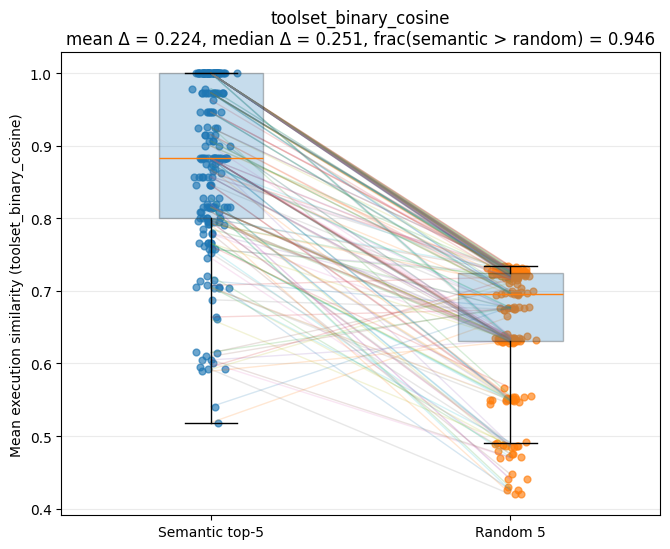

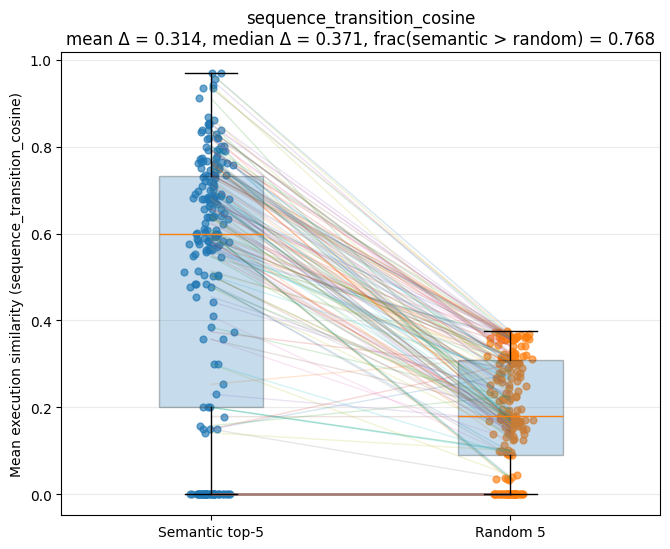

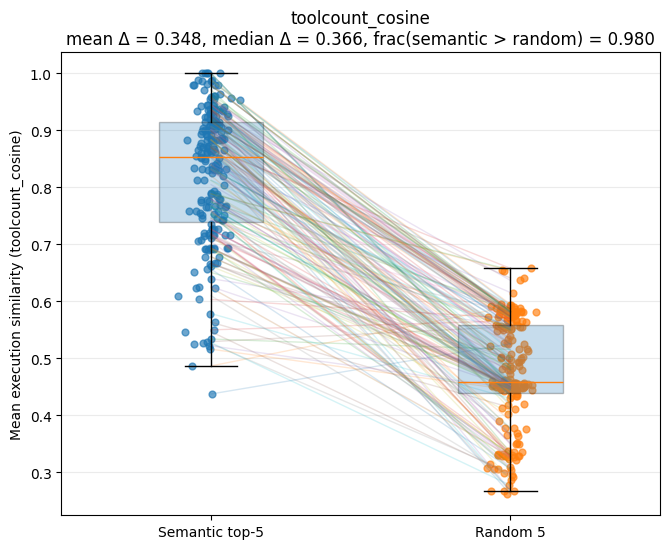

In [11]:
# ============================================================
# Neighborhood vs random comparison
# Selected execution metrics:
#   1) toolset_binary_cosine
#   2) sequence_transition_cosine
#   3) toolcount_cosine
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

TOP_K = 5
N_RANDOM_TRIALS = 1000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

def topk_semantic_neighbors(S_sem, k):
    n = S_sem.shape[0]
    nbrs = []
    for i in range(n):
        order = np.argsort(-S_sem[i])  # descending semantic similarity
        order = [j for j in order if j != i]
        nbrs.append(order[:k])
    return nbrs

def semantic_neighbor_means(sim_matrix, semantic_neighbors):
    n = sim_matrix.shape[0]
    out = np.zeros(n, dtype=np.float64)
    for i in range(n):
        nbrs = semantic_neighbors[i]
        out[i] = float(np.mean(sim_matrix[i, nbrs]))
    return out

def random_neighbor_means(sim_matrix, k=3, n_trials=1000, seed=42):
    rng_local = np.random.default_rng(seed)
    n = sim_matrix.shape[0]
    out = np.zeros(n, dtype=np.float64)

    for i in range(n):
        candidates = np.array([j for j in range(n) if j != i], dtype=int)
        vals = []
        for _ in range(n_trials):
            chosen = rng_local.choice(candidates, size=k, replace=False)
            vals.append(np.mean(sim_matrix[i, chosen]))
        out[i] = float(np.mean(vals))
    return out

semantic_topk = topk_semantic_neighbors(S_sem, k=TOP_K)

metric_specs = [
    ("toolset_binary_cosine", S_exec_toolset_cosine),
    ("sequence_transition_cosine", S_exec_seq_transition_cosine),
    ("toolcount_cosine", S_exec_toolcount_cosine),
]

rows = []
metric_details = {}

for metric_name, S_exec in metric_specs:
    semantic_means = semantic_neighbor_means(S_exec, semantic_topk)
    random_means = random_neighbor_means(
        S_exec,
        k=TOP_K,
        n_trials=N_RANDOM_TRIALS,
        seed=RANDOM_SEED,
    )
    deltas = semantic_means - random_means

    try:
        w = wilcoxon(
            semantic_means,
            random_means,
            alternative="greater",
            zero_method="wilcox",
        )
        wilcoxon_stat = float(w.statistic)
        wilcoxon_p = float(w.pvalue)
    except Exception:
        wilcoxon_stat = np.nan
        wilcoxon_p = np.nan

    rows.append({
        "metric_name": metric_name,
        "top_k": TOP_K,
        "n_queries": len(semantic_means),
        "mean_semantic_neighbor_exec_sim": float(np.mean(semantic_means)),
        "mean_random_neighbor_exec_sim": float(np.mean(random_means)),
        "mean_delta": float(np.mean(deltas)),
        "median_delta": float(np.median(deltas)),
        "fraction_queries_semantic_beats_random": float(np.mean(deltas > 0)),
        "wilcoxon_stat": wilcoxon_stat,
        "wilcoxon_p_one_sided": wilcoxon_p,
    })

    metric_details[metric_name] = {
        "semantic_means": semantic_means,
        "random_means": random_means,
        "deltas": deltas,
    }

df_neighbor_vs_random = pd.DataFrame(rows).sort_values(
    by="mean_delta",
    ascending=False
).reset_index(drop=True)

print("Neighborhood vs random summary")
display(df_neighbor_vs_random)

# Plot one paired comparison figure per metric
for metric_name, _ in metric_specs:
    semantic_means = metric_details[metric_name]["semantic_means"]
    random_means = metric_details[metric_name]["random_means"]
    deltas = metric_details[metric_name]["deltas"]

    fig, ax = plt.subplots(figsize=(6.8, 5.6))

    x1 = np.full_like(semantic_means, 0, dtype=np.float64)
    x2 = np.full_like(random_means, 1, dtype=np.float64)

    jitter1 = rng.normal(0, 0.03, size=len(x1))
    jitter2 = rng.normal(0, 0.03, size=len(x2))

    for i in range(len(semantic_means)):
        ax.plot(
            [0, 1],
            [semantic_means[i], random_means[i]],
            alpha=0.18,
            linewidth=1.0,
        )

    ax.scatter(x1 + jitter1, semantic_means, alpha=0.65, s=24, label="Semantic top-k")
    ax.scatter(x2 + jitter2, random_means, alpha=0.65, s=24, label="Random k")

    bp = ax.boxplot(
        [semantic_means, random_means],
        positions=[0, 1],
        widths=0.35,
        patch_artist=True,
        showfliers=False,
    )
    for patch in bp["boxes"]:
        patch.set_alpha(0.25)

    ax.set_xticks([0, 1])
    ax.set_xticklabels([f"Semantic top-{TOP_K}", f"Random {TOP_K}"])
    ax.set_ylabel(f"Mean execution similarity ({metric_name})")
    ax.set_title(
        f"{metric_name}\n"
        f"mean Δ = {np.mean(deltas):.3f}, "
        f"median Δ = {np.median(deltas):.3f}, "
        f"frac(semantic > random) = {np.mean(deltas > 0):.3f}"
    )
    ax.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

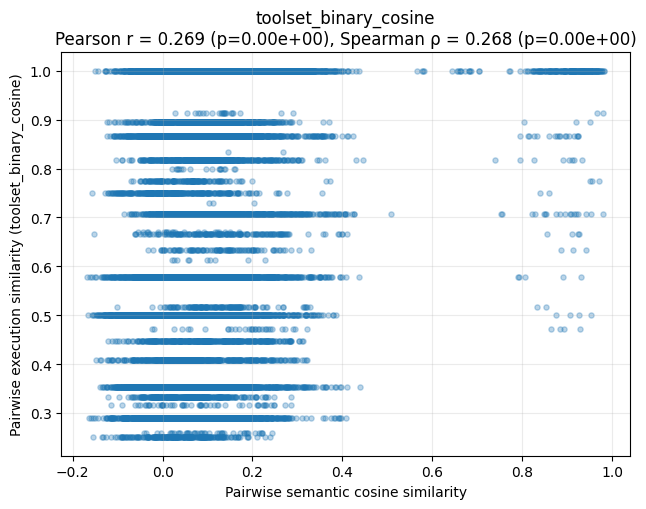

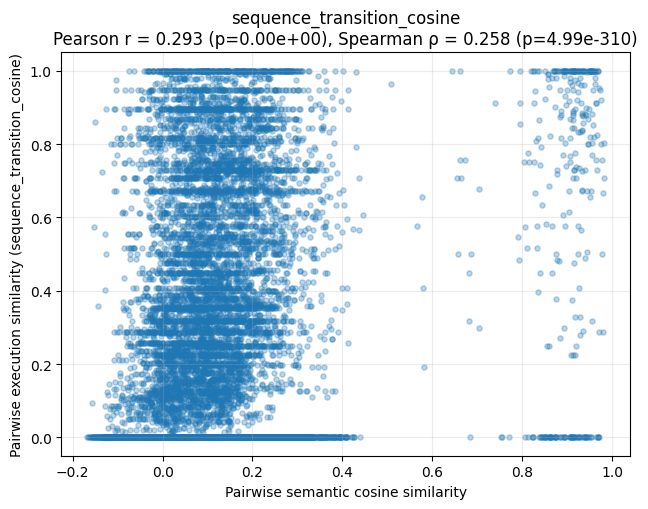

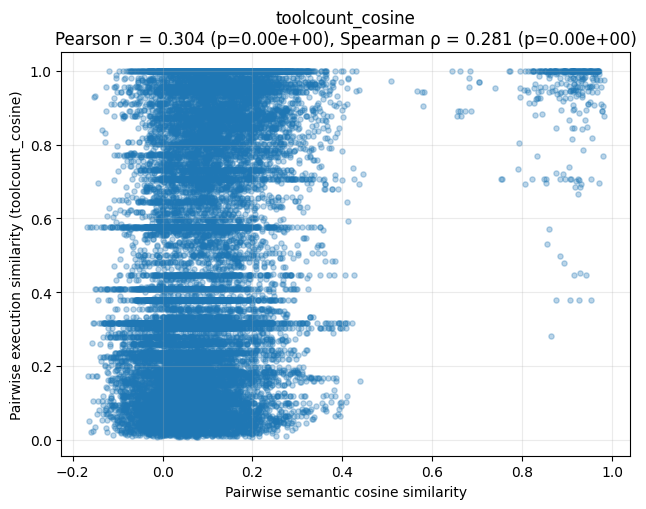

In [12]:
# ============================================================
# Raw scatter plots:
# x-axis = pairwise semantic cosine similarity
# y-axis = pairwise execution similarity
# Selected metrics only
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

def upper_triangle_values(M):
    idx = np.triu_indices_from(M, k=1)
    return M[idx]

x_sem = upper_triangle_values(S_sem)

scatter_specs = [
    ("toolset_binary_cosine", S_exec_toolset_cosine),
    ("sequence_transition_cosine", S_exec_seq_transition_cosine),
    ("toolcount_cosine", S_exec_toolcount_cosine),
]

for metric_name, M_exec in scatter_specs:
    y_exec = upper_triangle_values(M_exec)

    pearson_r, pearson_p = pearsonr(x_sem, y_exec)
    spearman_rho, spearman_p = spearmanr(x_sem, y_exec)

    plt.figure(figsize=(6.5, 5.2))
    plt.scatter(x_sem, y_exec, alpha=0.30, s=14)

    plt.xlabel("Pairwise semantic cosine similarity")
    plt.ylabel(f"Pairwise execution similarity ({metric_name})")
    plt.title(
        f"{metric_name}\n"
        f"Pearson r = {pearson_r:.3f} (p={pearson_p:.2e}), "
        f"Spearman ρ = {spearman_rho:.3f} (p={spearman_p:.2e})"
    )
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

#### Hexbin + binned median trend
A raw scatter draws every pairwise point separately. When we have lots of pairs, many points overlap and the figure becomes visually noisy.

- Hexbin: plot the density instead of raw points (i.e., how many points fall into each hexagon?)
- Binned median trend: divide the x-axis into bin. Inside each bin of semantic similarity, we compute the median of y-axis value. Then, we plot the median as a line.
- IQR (Interquartile range $Q_3-Q_1$)

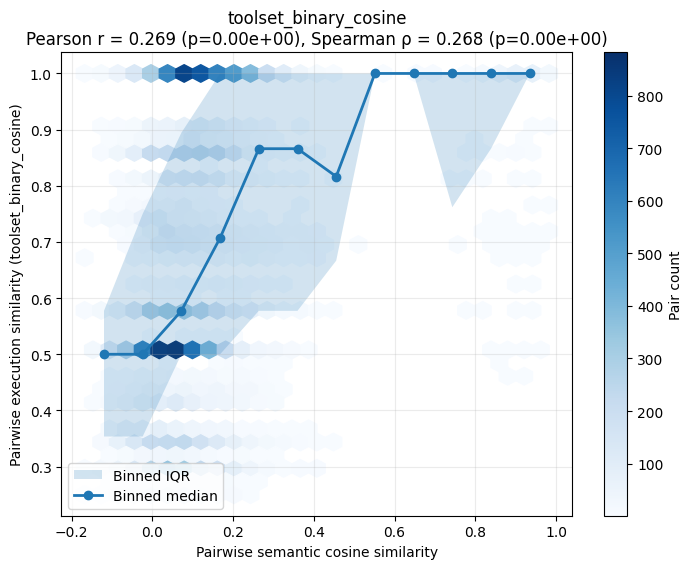

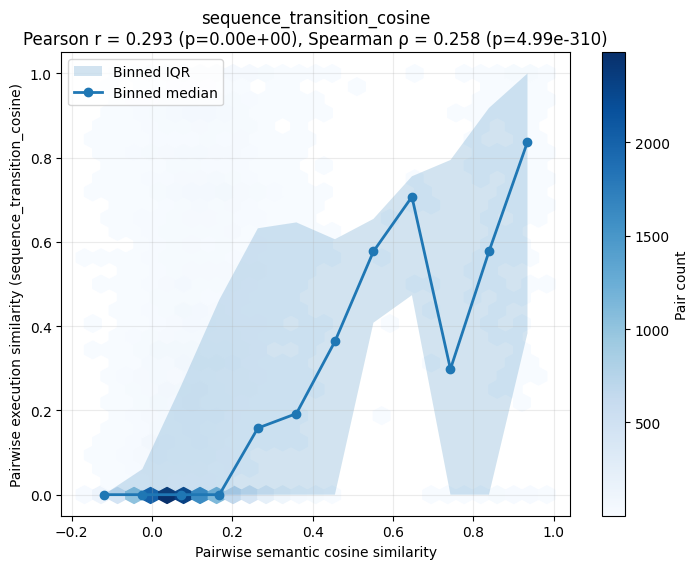

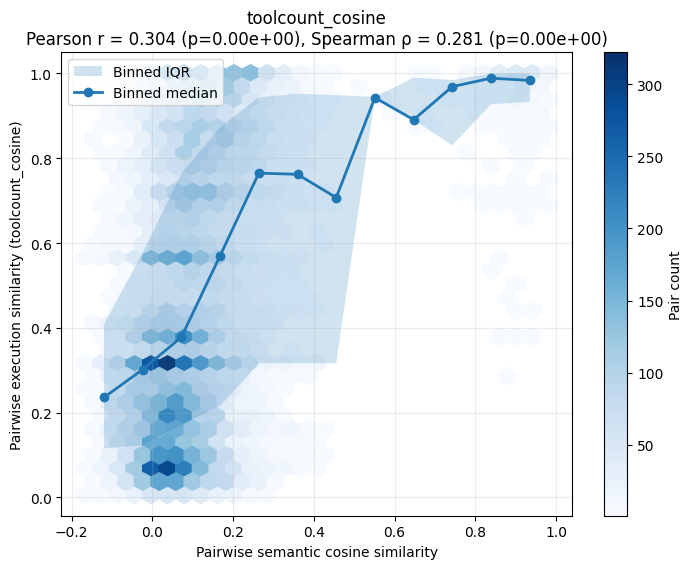

In [13]:
# ============================================================
# Hexbin + binned median trend
# Selected metrics:
#   1) toolset_binary_cosine
#   2) sequence_transition_cosine
#   3) toolcount_cosine
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

def upper_triangle_values(M):
    idx = np.triu_indices_from(M, k=1)
    return M[idx]

def compute_binned_stats(x, y, n_bins=12):
    x = np.asarray(x)
    y = np.asarray(y)

    finite_mask = np.isfinite(x) & np.isfinite(y)
    x = x[finite_mask]
    y = y[finite_mask]

    edges = np.linspace(x.min(), x.max(), n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    medians = np.full(n_bins, np.nan, dtype=np.float64)
    q25 = np.full(n_bins, np.nan, dtype=np.float64)
    q75 = np.full(n_bins, np.nan, dtype=np.float64)
    counts = np.zeros(n_bins, dtype=int)

    bin_ids = np.digitize(x, edges[1:-1], right=False)

    for b in range(n_bins):
        mask = (bin_ids == b)
        yb = y[mask]
        counts[b] = int(mask.sum())
        if len(yb) > 0:
            medians[b] = np.median(yb)
            q25[b] = np.percentile(yb, 25)
            q75[b] = np.percentile(yb, 75)

    return {
        "edges": edges,
        "centers": centers,
        "counts": counts,
        "median": medians,
        "q25": q25,
        "q75": q75,
    }

x_sem = upper_triangle_values(S_sem)

plot_specs = [
    ("toolset_binary_cosine", S_exec_toolset_cosine),
    ("sequence_transition_cosine", S_exec_seq_transition_cosine),
    ("toolcount_cosine", S_exec_toolcount_cosine),
]

N_BINS = 12
GRIDSIZE = 28
MINCNT = 1

for metric_name, M_exec in plot_specs:
    y_exec = upper_triangle_values(M_exec)

    pearson_r, pearson_p = pearsonr(x_sem, y_exec)
    spearman_rho, spearman_p = spearmanr(x_sem, y_exec)

    stats = compute_binned_stats(x_sem, y_exec, n_bins=N_BINS)
    centers = stats["centers"]
    medians = stats["median"]
    q25 = stats["q25"]
    q75 = stats["q75"]
    valid = np.isfinite(medians)

    fig, ax = plt.subplots(figsize=(7.2, 5.8))

    hb = ax.hexbin(
        x_sem,
        y_exec,
        gridsize=GRIDSIZE,
        mincnt=MINCNT,
        cmap="Blues",
    )
    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Pair count")

    if np.any(valid):
        ax.fill_between(
            centers[valid],
            q25[valid],
            q75[valid],
            alpha=0.20,
            label="Binned IQR",
        )

        ax.plot(
            centers[valid],
            medians[valid],
            marker="o",
            linewidth=2.0,
            label="Binned median",
        )

    ax.set_xlabel("Pairwise semantic cosine similarity")
    ax.set_ylabel(f"Pairwise execution similarity ({metric_name})")
    ax.set_title(
        f"{metric_name}\n"
        f"Pearson r = {pearson_r:.3f} (p={pearson_p:.2e}), "
        f"Spearman ρ = {spearman_rho:.3f} (p={spearman_p:.2e})"
    )
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

In [14]:
# ============================================================
# Recover semantic cluster labels from the notebook state
# ============================================================

import numpy as np

if "semantic_cluster" in df.columns:
    semantic_cluster_labels = df["semantic_cluster"].to_numpy()
elif "semantic_cluster_label" in df.columns:
    semantic_cluster_labels = df["semantic_cluster_label"].to_numpy()
elif "labels_semantic" in globals():
    semantic_cluster_labels = np.asarray(labels_semantic)
elif "best_kmeans" in globals() and isinstance(best_kmeans, dict) and "labels" in best_kmeans:
    semantic_cluster_labels = np.asarray(best_kmeans["labels"])
elif "best_semantic" in globals() and isinstance(best_semantic, dict) and "labels" in best_semantic:
    semantic_cluster_labels = np.asarray(best_semantic["labels"])
else:
    raise ValueError(
        "Could not find semantic cluster labels. "
        "Please store them in df['semantic_cluster'] or set semantic_cluster_labels manually."
    )

semantic_cluster_labels = np.asarray(semantic_cluster_labels)
if len(semantic_cluster_labels) != len(df):
    raise ValueError(
        f"semantic_cluster_labels has length {len(semantic_cluster_labels)}, "
        f"but df has length {len(df)}"
    )

print("Semantic cluster labels recovered.")
print("Unique semantic clusters:", np.unique(semantic_cluster_labels))

Semantic cluster labels recovered.
Unique semantic clusters: [0 1 2 3 4 5 6 7 8 9]


#### Cluster-pair scatter plots
Within-cluster pairs
- collects all query pairs inside the same cluste
- $\{(i, j)| i \in C_a, j\in C_a, i<j \}$

Between-cluster pairs
- collects all query pairs inside the same cluste
- $\{(i, j)| i \in C_a, j\in C_b\}$

In [15]:
# ============================================================
# UMAP of prompt embeddings, colored by execution representation
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

# ------------------------------------------------------------
# UMAP on prompt embeddings
# ------------------------------------------------------------
try:
    import umap.umap_ as umap
except Exception as e:
    raise ImportError(
        "UMAP is not available. Install with `pip install umap-learn`."
    ) from e

umap_model = umap.UMAP(
    n_neighbors=10,
    min_dist=0.20,
    metric="cosine",
    random_state=42,
)

X_umap = umap_model.fit_transform(X_embed)

print("UMAP coordinates shape:", X_umap.shape)

UMAP coordinates shape: (203, 2)


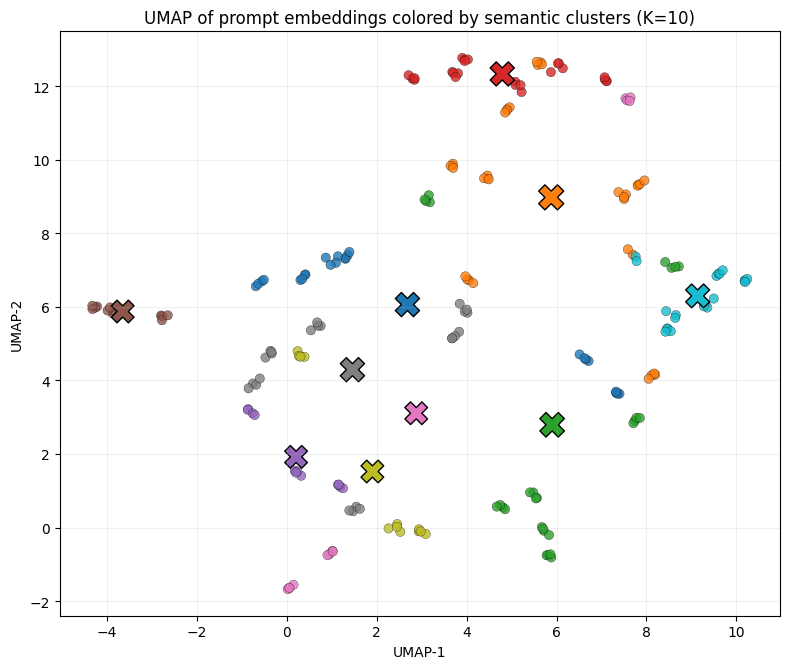

In [16]:
# ============================================================
# Visualize 16 semantic clusters on the UMAP coordinates
# This block also sets semantic_cluster_labels for downstream
# cluster-based analyses.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ------------------------------------------------------------
# Config
# ------------------------------------------------------------
K_SEMANTIC_VIZ = 10
RANDOM_STATE = 42

# ------------------------------------------------------------
# Recompute semantic clusters directly from prompt embeddings
# ------------------------------------------------------------
kmeans_semantic_viz = KMeans(
    n_clusters=K_SEMANTIC_VIZ,
    n_init=20,
    random_state=RANDOM_STATE,
)
semantic_cluster_labels = kmeans_semantic_viz.fit_predict(X_embed)

# keep in df for convenience
df["semantic_cluster"] = semantic_cluster_labels

# ------------------------------------------------------------
# Compute UMAP centroids of semantic clusters
# ------------------------------------------------------------
cluster_ids = np.sort(np.unique(semantic_cluster_labels))
centroids_umap = []
cluster_sizes = []

for c in cluster_ids:
    idx = np.where(semantic_cluster_labels == c)[0]
    centroids_umap.append(X_umap[idx].mean(axis=0))
    cluster_sizes.append(len(idx))

centroids_umap = np.asarray(centroids_umap)
cluster_sizes = np.asarray(cluster_sizes)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
cmap = plt.get_cmap("tab10" if K_SEMANTIC_VIZ <= 10 else "tab20")

fig, ax = plt.subplots(figsize=(8.0, 6.8))

# query points
ax.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=semantic_cluster_labels,
    cmap=cmap,
    s=45,
    alpha=0.80,
    edgecolors="black",
    linewidths=0.25,
)

# centroid markers
centroid_sizes = 180 + 25 * np.sqrt(cluster_sizes)
ax.scatter(
    centroids_umap[:, 0],
    centroids_umap[:, 1],
    s=centroid_sizes,
    c=cluster_ids,
    cmap=cmap,
    marker="X",
    edgecolors="black",
    linewidths=1.0,
)

# # annotate centroids with cluster id and size
# for c, (cx, cy), n in zip(cluster_ids, centroids_umap, cluster_sizes):
#     ax.text(
#         cx,
#         cy,
#         f"C{c}\n(n={n})",
#         fontsize=9,
#         ha="center",
#         va="center",
#         bbox=dict(boxstyle="round,pad=0.2", alpha=0.65),
#     )

ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_title(f"UMAP of prompt embeddings colored by semantic clusters (K={K_SEMANTIC_VIZ})")
ax.grid(True, alpha=0.20)

plt.tight_layout()
plt.show()

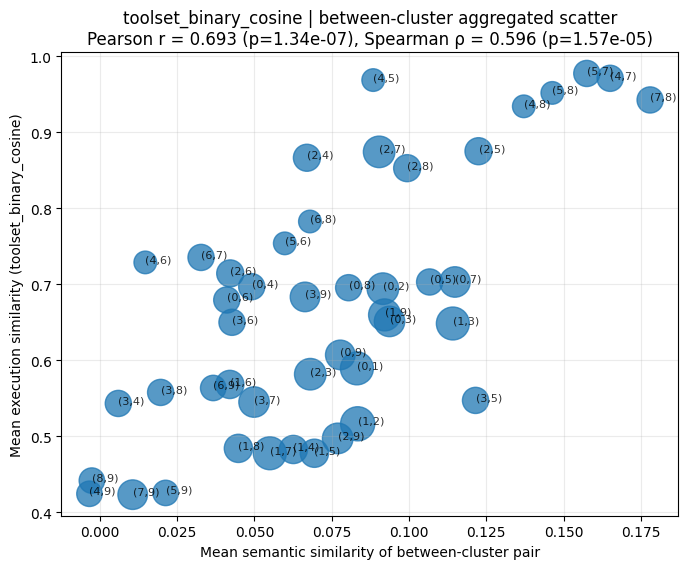

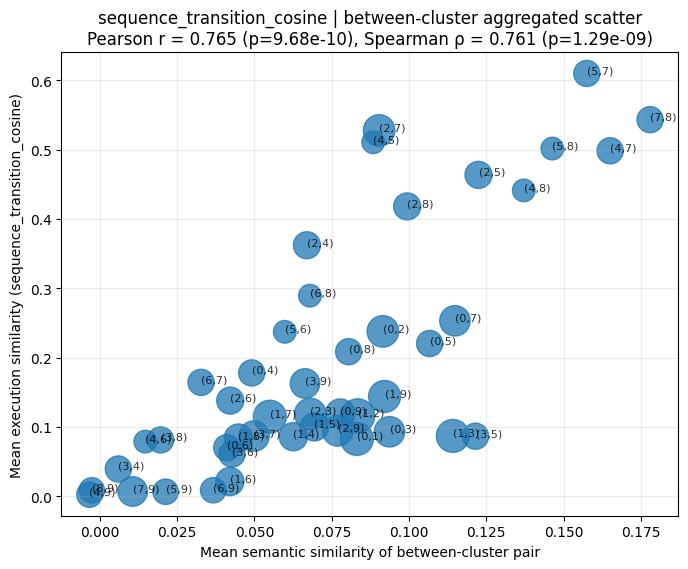

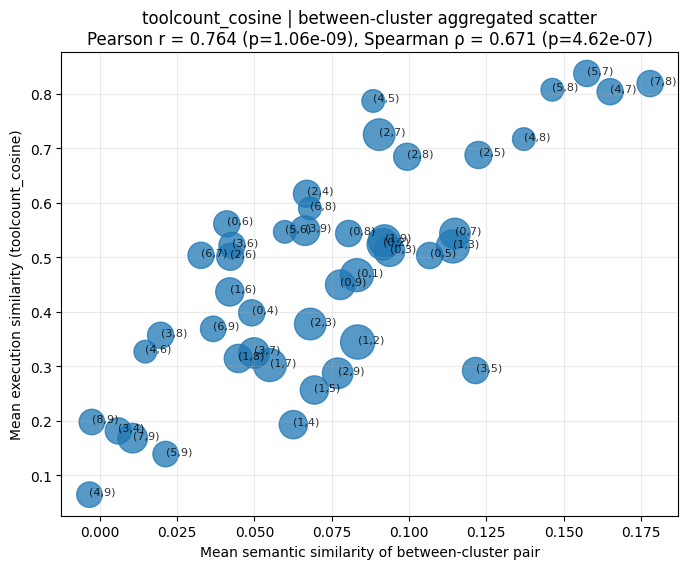

In [17]:
# ============================================================
# Cluster-pair aggregated scatter plots
# Updated to match the earlier blocks:
#   - uses semantic_cluster_labels from the semantic-cluster UMAP block
#   - separates within-cluster pairs and between-cluster pairs
#   - produces 6 plots total (2 pair types x 3 metrics)
#
# One point = one semantic-cluster pair
# x-axis = mean semantic similarity among all query pairs in that cluster pair
# y-axis = mean execution similarity among all query pairs in that cluster pair
# size   = number of contributing query pairs
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------
required_names = [
    "S_sem",
    "S_exec_toolset_cosine",
    "S_exec_seq_transition_cosine",
    "S_exec_toolcount_cosine",
    "semantic_cluster_labels",
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise ValueError(f"Missing required objects in notebook state: {missing}")

semantic_cluster_labels = np.asarray(semantic_cluster_labels)
if len(semantic_cluster_labels) != len(df):
    raise ValueError(
        f"semantic_cluster_labels has length {len(semantic_cluster_labels)} "
        f"but df has length {len(df)}"
    )

# ------------------------------------------------------------
# Helper: aggregate one point per unordered cluster pair (a, b), a <= b
# ------------------------------------------------------------
def cluster_pair_records(S_sem, S_exec, labels):
    """
    Build one aggregated record per unordered semantic-cluster pair (a, b), a <= b.

    For a == b:
        - use all within-cluster query pairs (i, j), i < j
    For a != b:
        - use all cross-cluster query pairs (i in a, j in b)

    Returns a dataframe where each row is one aggregated cluster-pair point.
    """
    labels = np.asarray(labels)
    clusters = np.sort(np.unique(labels))

    records = []
    for idx_a, a in enumerate(clusters):
        members_a = np.where(labels == a)[0]

        for b in clusters[idx_a:]:
            members_b = np.where(labels == b)[0]

            if a == b:
                # Within-cluster query pairs
                if len(members_a) < 2:
                    continue

                sub_sem = S_sem[np.ix_(members_a, members_a)]
                sub_exec = S_exec[np.ix_(members_a, members_a)]
                tri = np.triu_indices(len(members_a), k=1)

                sem_vals = sub_sem[tri]
                exec_vals = sub_exec[tri]
                pair_type = "within"
            else:
                # Between-cluster query pairs
                sub_sem = S_sem[np.ix_(members_a, members_b)]
                sub_exec = S_exec[np.ix_(members_a, members_b)]

                sem_vals = sub_sem.reshape(-1)
                exec_vals = sub_exec.reshape(-1)
                pair_type = "between"

            finite_mask = np.isfinite(sem_vals) & np.isfinite(exec_vals)
            sem_vals = sem_vals[finite_mask]
            exec_vals = exec_vals[finite_mask]

            if len(sem_vals) == 0:
                continue

            records.append({
                "cluster_a": int(a),
                "cluster_b": int(b),
                "pair_type": pair_type,
                "n_pairs": int(len(sem_vals)),
                "mean_semantic_similarity": float(np.mean(sem_vals)),
                "median_semantic_similarity": float(np.median(sem_vals)),
                "mean_execution_similarity": float(np.mean(exec_vals)),
                "median_execution_similarity": float(np.median(exec_vals)),
            })

    return pd.DataFrame(records)

# ------------------------------------------------------------
# Metrics to analyze
# ------------------------------------------------------------
metric_specs = [
    ("toolset_binary_cosine", S_exec_toolset_cosine),
    ("sequence_transition_cosine", S_exec_seq_transition_cosine),
    ("toolcount_cosine", S_exec_toolcount_cosine),
]

cluster_pair_tables = {}

# ------------------------------------------------------------
# Plot helper: one figure for one metric + one pair type
# ------------------------------------------------------------
def plot_cluster_pair_subset(df_cluster_pairs, metric_name, pair_type):
    sub = df_cluster_pairs[df_cluster_pairs["pair_type"] == pair_type].copy()
    if len(sub) == 0:
        print(f"No rows for metric={metric_name}, pair_type={pair_type}")
        return

    x = sub["mean_semantic_similarity"].to_numpy()
    y = sub["mean_execution_similarity"].to_numpy()

    # Correlation only makes sense if there are at least 2 non-constant points
    if len(sub) >= 2 and np.std(x) > 0 and np.std(y) > 0:
        pearson_r, pearson_p = pearsonr(x, y)
        spearman_rho, spearman_p = spearmanr(x, y)
        corr_text = (
            f"Pearson r = {pearson_r:.3f} (p={pearson_p:.2e}), "
            f"Spearman ρ = {spearman_rho:.3f} (p={spearman_p:.2e})"
        )
    else:
        pearson_r, pearson_p = np.nan, np.nan
        spearman_rho, spearman_p = np.nan, np.nan
        corr_text = "Correlation unavailable (too few or constant points)"

    fig, ax = plt.subplots(figsize=(7.0, 5.8))

    # marker sizes scaled by sqrt(pair_count) so huge clusters do not dominate
    sizes = 50 + 18 * np.sqrt(sub["n_pairs"].to_numpy())

    marker = "D" if pair_type == "within" else "o"
    alpha = 0.90 if pair_type == "within" else 0.75

    ax.scatter(
        x,
        y,
        s=sizes,
        alpha=alpha,
        marker=marker,
    )

    # annotate points by cluster pair
    for _, row in sub.iterrows():
        ax.text(
            row["mean_semantic_similarity"],
            row["mean_execution_similarity"],
            f"({row['cluster_a']},{row['cluster_b']})",
            fontsize=8,
            alpha=0.8,
        )

    ax.set_xlabel(f"Mean semantic similarity of {pair_type}-cluster pair")
    ax.set_ylabel(f"Mean execution similarity ({metric_name})")
    ax.set_title(
        f"{metric_name} | {pair_type}-cluster aggregated scatter\n{corr_text}"
    )
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    return {
        "metric_name": metric_name,
        "pair_type": pair_type,
        "n_points": int(len(sub)),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p,
        "mean_x": float(np.mean(x)),
        "mean_y": float(np.mean(y)),
    }

# ------------------------------------------------------------
# Build tables and make 6 plots
# ------------------------------------------------------------
summary_rows = []

for metric_name, S_exec in metric_specs:
    df_cluster_pairs = cluster_pair_records(S_sem, S_exec, semantic_cluster_labels)
    cluster_pair_tables[metric_name] = df_cluster_pairs

    # # Optional: inspect the full aggregated table
    # print(f"\nAggregated cluster-pair table for {metric_name}")
    # display(df_cluster_pairs.sort_values(
    #     by=["pair_type", "mean_semantic_similarity"],
    #     ascending=[True, False]
    # ).reset_index(drop=True))

    # # within-cluster plot
    # out_within = plot_cluster_pair_subset(
    #     df_cluster_pairs=df_cluster_pairs,
    #     metric_name=metric_name,
    #     pair_type="within",
    # )
    # if out_within is not None:
    #     summary_rows.append(out_within)

    # between-cluster plot
    out_between = plot_cluster_pair_subset(
        df_cluster_pairs=df_cluster_pairs,
        metric_name=metric_name,
        pair_type="between",
    )
    if out_between is not None:
        summary_rows.append(out_between)

df_cluster_pair_corr_summary = pd.DataFrame(summary_rows)

# print("\nCluster-pair aggregated scatter summary")
# display(df_cluster_pair_corr_summary)

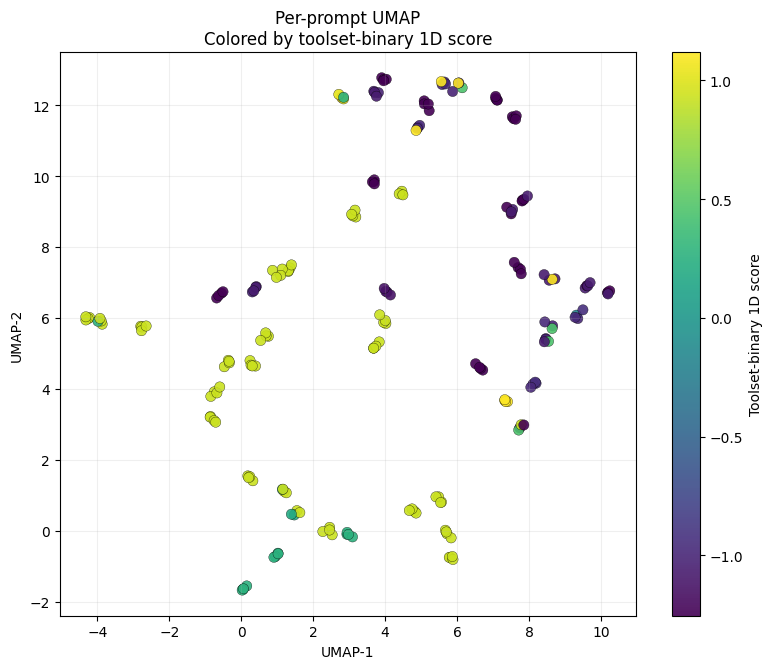

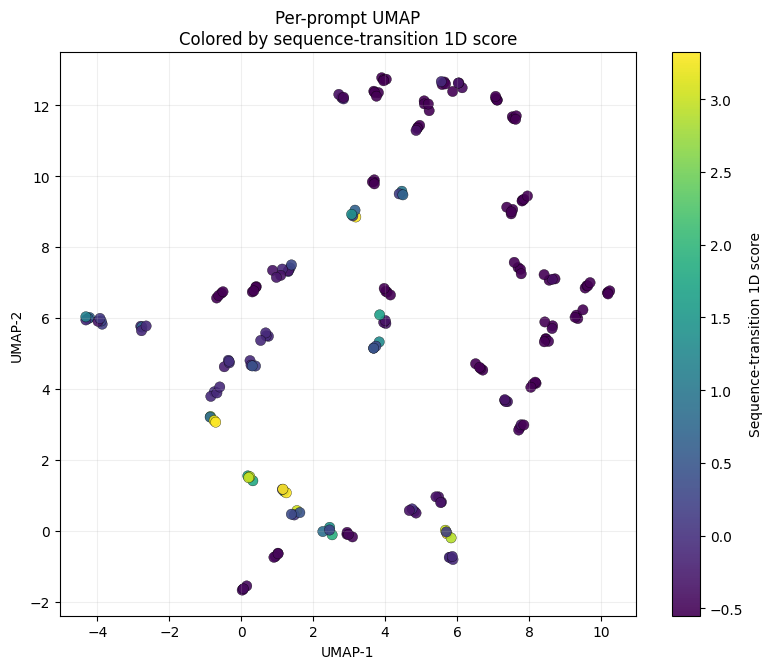

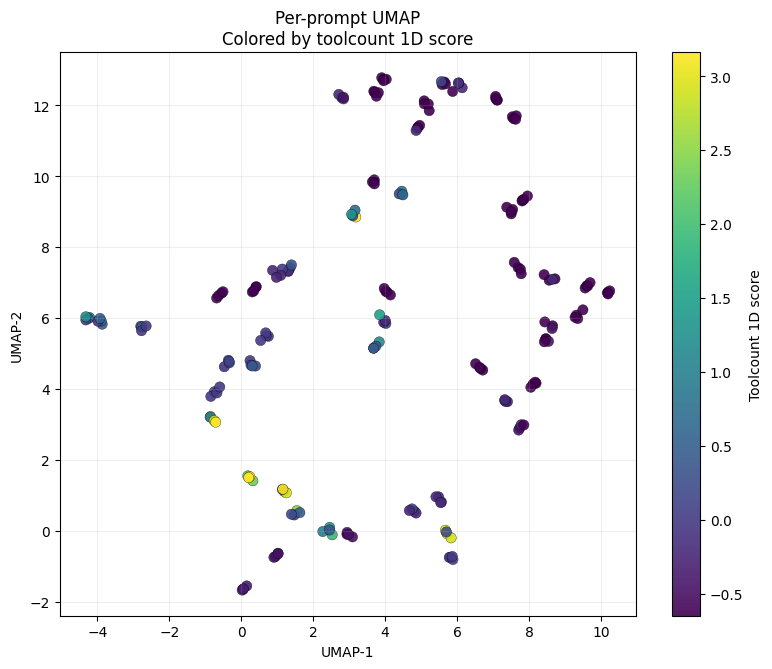

In [18]:
# ============================================================
# Per-prompt UMAP
# - each point = one prompt
# - point position from X_umap
# - point color = per-prompt 1D-projected execution score
#   (toolset_binary / sequence_transition / toolcount)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

# ------------------------------------------------------------
# Fallback helper if not already defined
# ------------------------------------------------------------
if "first_component_score" not in globals():
    def first_component_score(X, name="X"):
        """
        Reduce a feature matrix X (n_samples, n_features) to a single
        continuous score using the first TruncatedSVD component.
        Then z-score it for easier color interpretation.
        """
        X = np.asarray(X, dtype=np.float32)

        if X.ndim != 2:
            raise ValueError(f"{name} must be 2D, got shape={X.shape}")

        if X.shape[1] == 0:
            raise ValueError(f"{name} has zero columns.")

        if X.shape[1] == 1:
            score = X[:, 0].astype(np.float32)
        else:
            svd = TruncatedSVD(n_components=1, random_state=42)
            score = svd.fit_transform(X).reshape(-1).astype(np.float32)

        mu = float(np.mean(score))
        sigma = float(np.std(score))
        if sigma == 0:
            sigma = 1.0
        score_z = (score - mu) / sigma
        return score_z

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------
required_names = ["X_umap", "X_toolset_binary", "X_tool_transition", "X_toolcount"]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise ValueError(f"Missing required objects in notebook state: {missing}")

# ------------------------------------------------------------
# Per-prompt 1D execution scores
# ------------------------------------------------------------
score_toolset_binary = first_component_score(X_toolset_binary, name="X_toolset_binary")
score_sequence_transition = first_component_score(X_tool_transition, name="X_tool_transition")
score_toolcount = first_component_score(X_toolcount, name="X_toolcount")

# Optional: keep them in df for later inspection
df["score_toolset_binary_1d"] = score_toolset_binary
df["score_sequence_transition_1d"] = score_sequence_transition
df["score_toolcount_1d"] = score_toolcount

# ------------------------------------------------------------
# Plot helper
# ------------------------------------------------------------
def plot_per_prompt_umap(
    X_umap,
    color_values,
    title,
    cbar_label,
    clip_percentile=2.0,
):
    """
    Plot per-prompt UMAP colored by a continuous score.

    clip_percentile:
      clips color range to [p, 100-p] percentile to reduce outlier domination.
    """
    color_values = np.asarray(color_values, dtype=np.float32)

    # clip color scale for readability
    if clip_percentile is not None and 0 < clip_percentile < 50:
        vmin = np.percentile(color_values, clip_percentile)
        vmax = np.percentile(color_values, 100 - clip_percentile)
    else:
        vmin = float(np.min(color_values))
        vmax = float(np.max(color_values))

    plt.figure(figsize=(8.0, 6.8))
    sc = plt.scatter(
        X_umap[:, 0],
        X_umap[:, 1],
        c=color_values,
        s=55,
        alpha=0.90,
        edgecolors="black",
        linewidths=0.25,
        vmin=vmin,
        vmax=vmax,
    )

    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.title(title)
    plt.grid(True, alpha=0.20)

    cbar = plt.colorbar(sc)
    cbar.set_label(cbar_label)

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Three per-prompt UMAP plots
# ------------------------------------------------------------
plot_per_prompt_umap(
    X_umap=X_umap,
    color_values=score_toolset_binary,
    title="Per-prompt UMAP\nColored by toolset-binary 1D score",
    cbar_label="Toolset-binary 1D score",
)

plot_per_prompt_umap(
    X_umap=X_umap,
    color_values=score_sequence_transition,
    title="Per-prompt UMAP\nColored by sequence-transition 1D score",
    cbar_label="Sequence-transition 1D score",
)

plot_per_prompt_umap(
    X_umap=X_umap,
    color_values=score_toolcount,
    title="Per-prompt UMAP\nColored by toolcount 1D score",
    cbar_label="Toolcount 1D score",
)

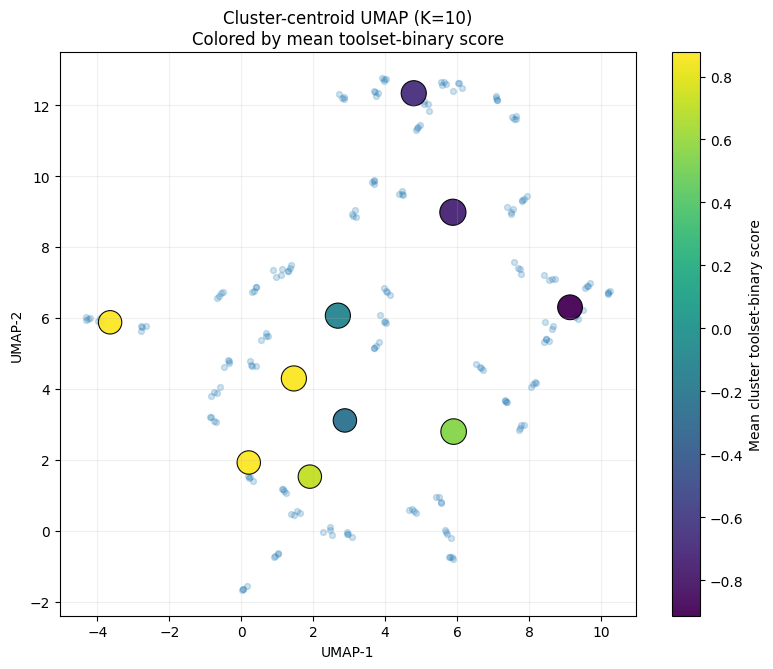

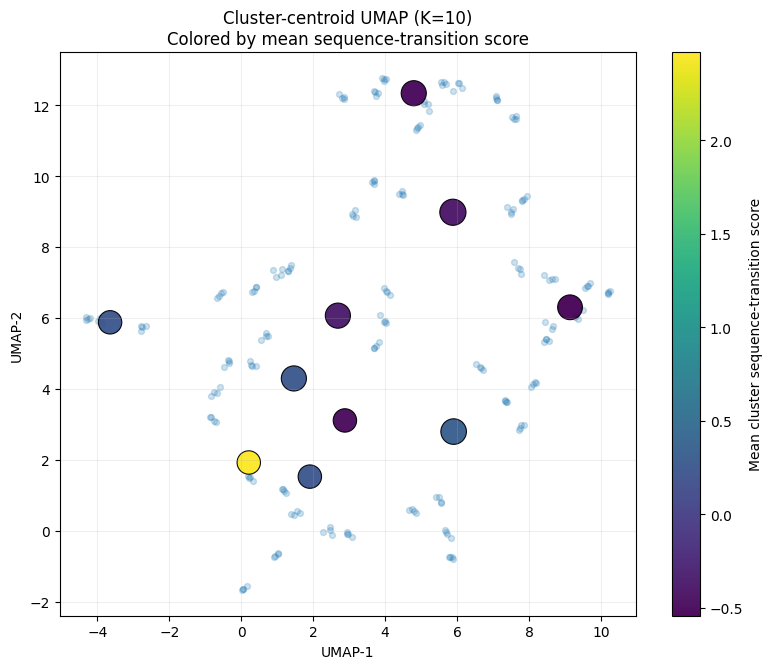

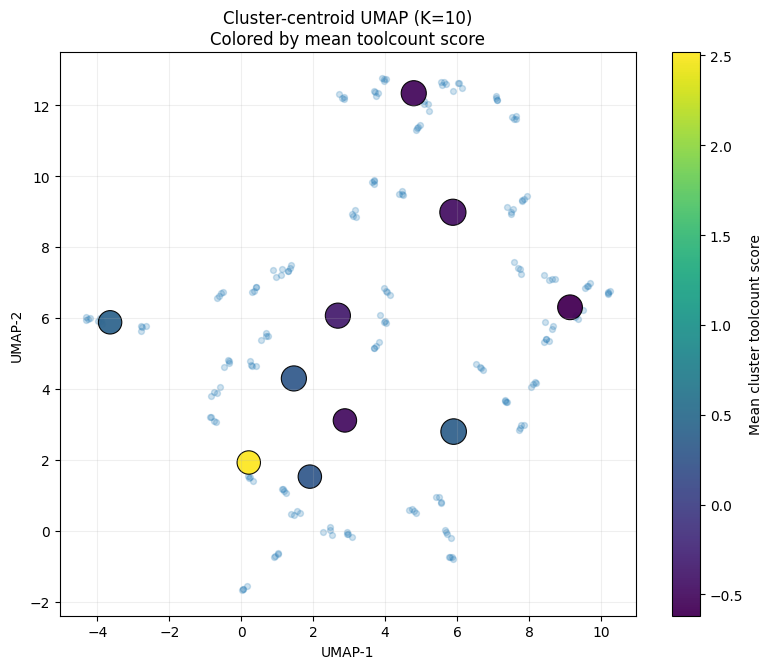

In [19]:
# ============================================================
# Cluster-centroid UMAP
# - configurable number of semantic clusters
# - centroid position from UMAP coordinates
# - point size = cluster size
# - point color = mean cluster execution score
#   (toolset_binary / sequence_transition / toolcount)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

# ------------------------------------------------------------
# Fallback helper if not already defined
# ------------------------------------------------------------
if "first_component_score" not in globals():
    def first_component_score(X, name="X"):
        """
        Reduce a feature matrix X (n_samples, n_features) to a single
        continuous score using the first TruncatedSVD component.
        Then z-score it for easier color interpretation.
        """
        X = np.asarray(X, dtype=np.float32)

        if X.ndim != 2:
            raise ValueError(f"{name} must be 2D, got shape={X.shape}")

        if X.shape[1] == 0:
            raise ValueError(f"{name} has zero columns.")

        if X.shape[1] == 1:
            score = X[:, 0].astype(np.float32)
        else:
            svd = TruncatedSVD(n_components=1, random_state=42)
            score = svd.fit_transform(X).reshape(-1).astype(np.float32)

        mu = float(np.mean(score))
        sigma = float(np.std(score))
        if sigma == 0:
            sigma = 1.0
        score_z = (score - mu) / sigma
        return score_z

# ------------------------------------------------------------
# Config
# ------------------------------------------------------------
K_CENTROID = K_SEMANTIC_VIZ
RANDOM_STATE = 42

# ------------------------------------------------------------
# Recompute semantic clusters with configurable K
# ------------------------------------------------------------
kmeans_centroid = KMeans(
    n_clusters=K_CENTROID,
    n_init=20,
    random_state=RANDOM_STATE,
)
semantic_cluster_labels_centroid = kmeans_centroid.fit_predict(X_embed)

df["semantic_cluster_centroid"] = semantic_cluster_labels_centroid

# ------------------------------------------------------------
# Per-query execution scores from high-dimensional representations
# ------------------------------------------------------------
score_toolset_binary = first_component_score(X_toolset_binary, name="X_toolset_binary")
score_sequence_transition = first_component_score(X_tool_transition, name="X_tool_transition")
score_toolcount = first_component_score(X_toolcount, name="X_toolcount")

# ------------------------------------------------------------
# Aggregate to cluster centroids
# ------------------------------------------------------------
cluster_ids = np.sort(np.unique(semantic_cluster_labels_centroid))

centroid_xy = []
cluster_sizes = []
cluster_mean_toolset = []
cluster_mean_sequence = []
cluster_mean_toolcount = []

for c in cluster_ids:
    idx = np.where(semantic_cluster_labels_centroid == c)[0]

    centroid_xy.append(X_umap[idx].mean(axis=0))
    cluster_sizes.append(len(idx))
    cluster_mean_toolset.append(float(np.mean(score_toolset_binary[idx])))
    cluster_mean_sequence.append(float(np.mean(score_sequence_transition[idx])))
    cluster_mean_toolcount.append(float(np.mean(score_toolcount[idx])))

centroid_xy = np.asarray(centroid_xy)
cluster_sizes = np.asarray(cluster_sizes)
cluster_mean_toolset = np.asarray(cluster_mean_toolset)
cluster_mean_sequence = np.asarray(cluster_mean_sequence)
cluster_mean_toolcount = np.asarray(cluster_mean_toolcount)

# ------------------------------------------------------------
# Plot helper
# ------------------------------------------------------------
def plot_cluster_centroid_umap(
    centroid_xy,
    cluster_sizes,
    cluster_ids,
    color_values,
    title,
    cbar_label,
):
    fig, ax = plt.subplots(figsize=(8.0, 6.8))

    # background: all query points in gray
    ax.scatter(
        X_umap[:, 0],
        X_umap[:, 1],
        s=18,
        alpha=0.22,
    )

    sizes = 180 + 30 * np.sqrt(cluster_sizes)

    sc = ax.scatter(
        centroid_xy[:, 0],
        centroid_xy[:, 1],
        s=sizes,
        c=color_values,
        alpha=0.95,
        edgecolors="black",
        linewidths=0.8,
    )

    # for cid, (cx, cy), n in zip(cluster_ids, centroid_xy, cluster_sizes):
    #     ax.text(
    #         cx,
    #         cy,
    #         f"C{cid}\n(n={n})",
    #         fontsize=9,
    #         ha="center",
    #         va="center",
    #         bbox=dict(boxstyle="round,pad=0.18", alpha=0.65),
    #     )

    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.set_title(title)
    ax.grid(True, alpha=0.20)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(cbar_label)

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Three centroid UMAP plots
# ------------------------------------------------------------
plot_cluster_centroid_umap(
    centroid_xy=centroid_xy,
    cluster_sizes=cluster_sizes,
    cluster_ids=cluster_ids,
    color_values=cluster_mean_toolset,
    title=f"Cluster-centroid UMAP (K={K_CENTROID})\nColored by mean toolset-binary score",
    cbar_label="Mean cluster toolset-binary score",
)

plot_cluster_centroid_umap(
    centroid_xy=centroid_xy,
    cluster_sizes=cluster_sizes,
    cluster_ids=cluster_ids,
    color_values=cluster_mean_sequence,
    title=f"Cluster-centroid UMAP (K={K_CENTROID})\nColored by mean sequence-transition score",
    cbar_label="Mean cluster sequence-transition score",
)

plot_cluster_centroid_umap(
    centroid_xy=centroid_xy,
    cluster_sizes=cluster_sizes,
    cluster_ids=cluster_ids,
    color_values=cluster_mean_toolcount,
    title=f"Cluster-centroid UMAP (K={K_CENTROID})\nColored by mean toolcount score",
    cbar_label="Mean cluster toolcount score",
)

# Summary of Findings — gaia_lv1_x4

Analysis run on **203 normalized traces** from `traces/claude_native/gaia_lv1_x4`
(51 base GAIA Level-1 tasks × 4 variants each: original + 3 paraphrases; 1 trace missing due to persistent timeout).

---

## 1. Accuracy

| Metric | Value |
|---|---|
| Total traces | 203 |
| Successful completions | 203 (100%) |
| Overall exact-match accuracy | **80.79%** |

All collected traces completed successfully. Exact-match accuracy of 80.79% is notably high for GAIA Level 1, reflecting the capability of Claude Sonnet with web search tools.

---

## 2. Tool Usage Patterns

**Top tool sets (by frequency):**

| Tool set | Count | % |
|---|---|---|
| StructuredOutput + ToolSearch + WebFetch + WebSearch | 84 | 41.4% |
| StructuredOutput only | 43 | 21.2% |
| Bash + StructuredOutput | 18 | 8.9% |
| StructuredOutput + ToolSearch + WebSearch | 14 | 6.9% |
| Bash + Read + StructuredOutput | 11 | 5.4% |

- **41%** of traces followed the canonical web-search pipeline (search → fetch → answer), making it by far the dominant strategy.
- **21%** needed no tools at all beyond StructuredOutput — Claude answered directly from parametric knowledge (these tend to be simpler factual questions).
- **~15%** relied on local file reading (Bash, Read, Glob), typically tasks with attached files.
- 85 unique tool sequences were observed across 203 traces, indicating diverse execution strategies even within Level 1.

**Most common single sequences:**
1. `StructuredOutput` only (43 traces) — direct answer
2. `ToolSearch → WebSearch → ToolSearch → WebFetch → ... → StructuredOutput` (18+12 traces) — standard web lookup
3. `Bash → Bash → Bash → StructuredOutput` (9 traces) — local file computation

---

## 3. Semantic Clustering and Execution Variance

With K=10 semantic clusters (silhouette = 0.185):

| Feature | Within-cluster / Overall variance ratio | Variance explained by clusters |
|---|---|---|
| total_tokens | 0.493 | **~51%** |
| total_steps | 0.502 | **~50%** |
| total_latency_ms | 0.586 | **~41%** |

Semantic clusters explain roughly **half the variance** in steps and token usage, and ~41% of latency variance. This is substantially stronger than typically observed on non-paraphrased datasets (~25%), and is expected: paraphrase variants of the same base task cluster together semantically and tend to follow nearly identical tool strategies.

---

## 4. Semantic–Execution Correlation

All six execution similarity metrics show statistically significant positive correlation with prompt semantic similarity (all permutation p ≈ 0.005, all Spearman p ≈ 0):

| Metric | Spearman ρ | Pearson r |
|---|---|---|
| toolcount_cosine | **0.281** | 0.304 |
| sequence_levenshtein | 0.271 | 0.303 |
| toolset_jaccard | 0.269 | 0.283 |
| toolset_binary_cosine | 0.268 | 0.269 |
| sequence_transition_cosine | 0.258 | 0.293 |
| toolcount_manhattan | 0.163 | 0.157 |

- The strongest signal comes from **tool-count cosine and Levenshtein sequence similarity** (ρ ≈ 0.27–0.28), suggesting that how many times each tool is called is the most semantically predictable aspect of execution.
- Tool-count Manhattan distance is the weakest predictor, likely because it is sensitive to absolute scale differences rather than relative composition.
- Correlations are moderate — semantic similarity is informative but far from deterministic for predicting execution behavior.

---

## 5. Semantic Neighbors vs Random Neighbors

Comparing the mean execution similarity of a query's top-5 semantic neighbors vs 5 random queries:

| Metric | Mean Δ (semantic − random) | Fraction semantic > random | Wilcoxon p |
|---|---|---|---|
| toolcount_cosine | **+0.348** | **98.0%** | 3.2 × 10⁻³⁵ |
| sequence_transition_cosine | +0.314 | 76.8% | 4.8 × 10⁻²⁸ |
| toolset_binary_cosine | +0.224 | 94.6% | 1.8 × 10⁻³⁴ |

- For **98% of queries**, the top-5 semantically similar queries are more similar in tool-count execution than 5 random queries — a very strong and practically significant result.
- The sequence_transition metric shows a lower fraction (76.8%) but a large mean delta, meaning the effect is large when it occurs but slightly less consistent across queries.

---

## 6. Key Takeaways

1. **Semantic similarity is a reliable proxy for execution similarity** on GAIA Level 1: queries that ask the same thing differently tend to trigger similar tool strategies.
2. **The paraphrase structure amplifies this effect**: ~50% variance reduction in execution features within semantic clusters (vs ~25% on non-paraphrased data) confirms that paraphrase variants are tight semantic neighbors.
3. **Tool-count cosine is the best single execution similarity metric** for predicting semantic neighborhood — it outperforms both set-based (Jaccard) and sequence-based (Levenshtein, transition) metrics.
4. **21% of tasks can be answered without web search**, suggesting a meaningful fraction of Level 1 questions lie within Claude's parametric knowledge — relevant for caching or shortcutting strategies.
5. **These findings support the feasibility of plan/trace reuse**: if a semantically similar past task exists in a knowledge base, its execution trace (tool sequence, call counts) is likely a good starting template for the new task.